# Ablation Phase 1: Seeds & Imbalance Factors

This notebook is parameterized for rapid ablation testing. Change the `SEED` and `IMB_FACTOR` below to test the robustness of the Neural Entropy Router against statistical variance and dataset severity.

## 1. Environment Setup


In [1]:
!pip install timm==0.4.12 torch torchvision scikit-learn seaborn matplotlib scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 20.0 MB/s eta 0:00:00
  Attempting uninstall: timm
    Found existing installation: timm 1.0.26
    Uninstalling timm-1.0.26:
      Successfully uninstalled timm-1.0.26


## 2. Imports and Teacher Weights


In [2]:
import os
import time
import math
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from timm.data.mixup import Mixup
from timm.loss import SoftTargetCrossEntropy
from timm.scheduler import create_scheduler
from timm.optim import create_optimizer

# 1. Download Teacher Weights (IF 50)
teacher_url = "https://api.wandb.ai/artifactsV2/default/pradipto611/QXJ0aWZhY3Q6Nzk3NzA4NTEx/fc15814c0ce158e6987110b256248e18/paco_sam_ckpt_cf10_if50.pth.tar"
weight_path = "teacher_cifar10_lt_if50.pth"
if not os.path.exists(weight_path):
    print("Downloading Official ResNet-32 Teacher (IF=50)...")
    urllib.request.urlretrieve(teacher_url, weight_path)
    print("Downloaded!")



Downloaded!


## 3. Dataset Generation (CIFAR-10 LT)


In [3]:
# Exact Pareto distribution extraction used in the official paper
def make_long_tail(dataset, num_classes=10, imb_factor=0.02): # 0.02 = IF 50
    img_max = len(dataset.samples) / num_classes
    img_num_per_cls = []
    for cls_idx in range(num_classes):
        num = img_max * (imb_factor ** (cls_idx / (num_classes - 1.0)))
        img_num_per_cls.append(int(num))
        
    new_samples = []
    targets_np = np.array(dataset.targets)
    for the_class in range(num_classes):
        idx = np.where(targets_np == the_class)[0]
        np.random.shuffle(idx)
        selec_idx = idx[:img_num_per_cls[the_class]]
        for i in selec_idx:
            new_samples.append(dataset.samples[i])
            
    dataset.samples = new_samples
    dataset.targets = [s[1] for s in new_samples]
    return dataset, img_num_per_cls



## 4. Models (DeiT-Tiny Dual-Expert & ResNet-32 Teacher)


In [4]:
# --- TEACHER: ResNet-32 ---
import torch.nn.init as init
from torch.nn import Parameter

class LambdaLayer(nn.Module):
    def __init__(self, lambd):
        super(LambdaLayer, self).__init__()
        self.lambd = lambd
    def forward(self, x):
        return self.lambd(x)

class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = LambdaLayer(lambda x:
                                        F.pad(x[:, :, ::2, ::2], (0, 0, 0, 0, planes//4, planes//4), "constant", 0))
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet_s(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet_s, self).__init__()
        self.in_planes = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.linear = nn.Linear(64, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.avg_pool2d(out, out.size()[3])
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

def resnet32():
    return ResNet_s(BasicBlock, [5, 5, 5])

# --- STUDENT: DeiT-Tiny (Clean-room Implementation) ---
from timm.models.vision_transformer import Block

class DeiTLT(nn.Module):
    def __init__(self, img_size=224, patch_size=16, embed_dim=192, depth=12, num_heads=3, num_classes=10):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_embed = nn.Conv2d(3, embed_dim, kernel_size=patch_size, stride=patch_size)
        
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.dist_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 2, embed_dim))
        
        self.blocks = nn.ModuleList([Block(embed_dim, num_heads, mlp_ratio=4, qkv_bias=True) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        
        self.head_cls = nn.Linear(embed_dim, num_classes)
        self.head_dist = nn.Linear(embed_dim, num_classes)
        
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.dist_token, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
            
    def forward(self, x, return_features=False):
        B = x.shape[0]
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        dist_tokens = self.dist_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, dist_tokens, x), dim=1)
        x = x + self.pos_embed
        
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        
        logits_cls = self.head_cls(x[:, 0])
        logits_dist = self.head_dist(x[:, 1])
        if return_features:
            return logits_cls, logits_dist, x[:, 0], x[:, 1]
        return logits_cls, logits_dist



## 5. Main Training Pipeline


In [5]:
# ==========================================
# ABLATION CONFIGURATION (CHANGE THESE)
# ==========================================
GLOBAL_SEED = 100
IMBALANCE_FACTOR = 0.02 # 0.10=IF10, 0.02=IF50, 0.01=IF100
# ==========================================

import random
import numpy as np
import torch
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)

# --- Configuration ---
class Config:
    epochs = 300 
    batch_size = 256 # Increased for 2 GPUs
    lr = 1e-3        # Scaled with batch size
    warmup_epochs = 5
    drw_epoch = int(epochs * 0.9) # DRW in last 10%
    weight_decay = 0.05
    mixup = 0.8
    cutmix = 1.0
    imb_factor = IMBALANCE_FACTOR
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

args = Config()
import torch.backends.cudnn as cudnn
cudnn.benchmark = True # Speeds up CNNs

# --- Dataloaders ---
transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])
transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])
# Note: In Kaggle, use torchvision.datasets.CIFAR10 directly and extract it properly, 
# or use Kaggle Datasets for faster loading. For simplicity here:
cifar_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
cifar_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Convert CIFAR10 to ImageFolder-like format for our make_long_tail function
class CIFARWrapper:
    def __init__(self, ds):
        self.samples = [(img, target) for img, target in zip(ds.data, ds.targets)]
        self.targets = ds.targets
wrapped_train = CIFARWrapper(cifar_train)
lt_train, cls_distribution = make_long_tail(wrapped_train, imb_factor=args.imb_factor)
cifar_train.data = np.stack([s[0] for s in lt_train.samples])
cifar_train.targets = lt_train.targets

train_loader = DataLoader(cifar_train, batch_size=args.batch_size, shuffle=True, num_workers=4, pin_memory=True, drop_last=True)
test_loader = DataLoader(cifar_test, batch_size=args.batch_size, shuffle=False, num_workers=4, pin_memory=True)

print("Class distribution:", cls_distribution)

# --- Per Class Weights (for DRW) ---
beta = 0.9999
effective_num = 1.0 - np.power(beta, cls_distribution)
per_cls_weights = (1.0 - beta) / np.array(effective_num)
per_cls_weights = per_cls_weights / np.sum(per_cls_weights) * 10
per_cls_weights = torch.FloatTensor(per_cls_weights).to(args.device)

# --- Mixup ---
mixup_fn = Mixup(mixup_alpha=args.mixup, cutmix_alpha=args.cutmix, label_smoothing=0.1, num_classes=10)

# --- Teacher Load ---
teacher = resnet32()
ckpt = torch.load("teacher_cifar10_lt_if50.pth", map_location='cpu')
new_state_dict = {}
for k, v in ckpt['state_dict'].items():
    k = k.replace('module.', '')
    if k.startswith('encoder_q.'):
        if 'fc.' in k: continue
        new_state_dict[k.replace('encoder_q.', '')] = v
    elif k.startswith('linear.'):
        new_state_dict[k] = v
teacher.load_state_dict(new_state_dict, strict=False)
teacher = teacher.to(args.device)
if torch.cuda.device_count() > 1:
    teacher = nn.DataParallel(teacher)
teacher.eval()
for p in teacher.parameters(): p.requires_grad = False

# --- Student Model & Optimizer ---
model = DeiTLT().to(args.device)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
scaler = torch.amp.GradScaler('cuda')
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args.epochs)
base_criterion = SoftTargetCrossEntropy()

# --- Distillation Loss ---
def distillation_loss(student_logits, teacher_logits, temperature=3.0, hard=True):
    if hard:
        targets = teacher_logits.argmax(dim=1)
        return F.cross_entropy(student_logits, targets)
    else:
        log_prob_s = F.log_softmax(student_logits / temperature, dim=1)
        prob_t = F.softmax(teacher_logits / temperature, dim=1)
        return F.kl_div(log_prob_s, prob_t, reduction='batchmean') * (temperature ** 2)

# --- Training Loop ---
metrics_history = {
    'epoch': [], 'cls_acc': [], 'dist_acc': [], 'avg_acc': [],
    'head_acc': [], 'med_acc': [], 'tail_acc': [], 
    'cls_loss': [], 'dist_loss': [], 'cos_sim': [],
    'teacher_entropy': [], 'lr': [], 'time_sec': []
}

for epoch in range(args.epochs):
    epoch_start_time = time.time()
    model.train()
    total_loss, total_cls, total_dist = 0, 0, 0
    total_teacher_entropy = 0.0
    
    # DRW Logic
    use_drw = epoch >= args.drw_epoch
    weight = 2.0 if use_drw else 1.0
    
    for i, (images, targets) in enumerate(train_loader):
        images, targets = images.to(args.device), targets.to(args.device)
        
        # Disable Mixup during DRW phase (as per paper)
        if not use_drw:
            images, targets = mixup_fn(images, targets)
        else:
            targets = torch.nn.functional.one_hot(targets, num_classes=10).float()
            
        with torch.amp.autocast('cuda'):
            with torch.no_grad():
                # Teacher takes 32x32 for CIFAR
                images_32 = F.interpolate(images, size=(32, 32), mode='bilinear', align_corners=False)
                teacher_logits = teacher(images_32)
                
                # Compute Teacher Entropy
                prob_t = F.softmax(teacher_logits / 3.0, dim=1) # temp=3.0
                entropy = -(prob_t * torch.log(prob_t + 1e-8)).sum(dim=1).mean()
                total_teacher_entropy += entropy.item()
                
            logits_cls, logits_dist = model(images)
            
            if use_drw:
                loss_cls = F.cross_entropy(logits_cls, targets.argmax(dim=1), weight=per_cls_weights)
            else:
                loss_cls = base_criterion(logits_cls, targets)
                
            loss_dist = distillation_loss(logits_dist, teacher_logits, hard=True)
            loss = loss_cls + (weight * loss_dist)
            
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        
    current_lr = scheduler.get_last_lr()[0]
    scheduler.step()
    epoch_time = time.time() - epoch_start_time
    
    if (epoch + 1) % 10 == 0:
        # Evaluate
        model.eval()
        cls_correct, dist_correct, avg_correct = 0, 0, 0
        head_correct, med_correct, tail_correct = 0, 0, 0
        head_total, med_total, tail_total = 0, 0, 0
        total = 0
        cls_loss_test, dist_loss_test = 0.0, 0.0
        cos_sim_total = 0.0
        
        all_test_lbls = []
        all_test_preds_cls = []
        all_test_preds_dist = []
        
        with torch.no_grad():
            for imgs, lbls in test_loader:
                imgs, lbls = imgs.to(args.device), lbls.to(args.device)
                
                # Request raw features to compute Cosine Similarity
                l_cls, l_dist, f_cls, f_dist = model(imgs, return_features=True)
                    
                cls_loss_test += F.cross_entropy(l_cls, lbls).item()
                dist_loss_test += F.cross_entropy(l_dist, lbls).item()
                
                cos_sim_total += F.cosine_similarity(f_cls, f_dist, dim=-1).sum().item()
                
                l_avg = (l_cls + l_dist) / 2
                
                p_cls = l_cls.argmax(dim=1)
                p_dist = l_dist.argmax(dim=1)
                p_avg = l_avg.argmax(dim=1)
                
                # Save for final epoch confusion matrix
                if (epoch + 1) == args.epochs:
                    all_test_lbls.append(lbls.cpu())
                    all_test_preds_cls.append(p_cls.cpu())
                    all_test_preds_dist.append(p_dist.cpu())
                
                cls_correct += (p_cls == lbls).sum().item()
                dist_correct += (p_dist == lbls).sum().item()
                avg_correct += (p_avg == lbls).sum().item()
                
                # Group 0,1,2 = Head | 3,4,5,6 = Med | 7,8,9 = Tail
                for c_idx in range(10):
                    mask = (lbls == c_idx)
                    n_c = mask.sum().item()
                    c_correct = (p_avg[mask] == c_idx).sum().item()
                    
                    if c_idx <= 2:
                        head_total += n_c
                        head_correct += c_correct
                    elif c_idx <= 6:
                        med_total += n_c
                        med_correct += c_correct
                    else:
                        tail_total += n_c
                        tail_correct += c_correct
                        
                total += lbls.size(0)
                
        num_batches = len(test_loader)
        cls_acc = cls_correct / total * 100
        dist_acc = dist_correct / total * 100
        avg_acc = avg_correct / total * 100
        
        h_acc = (head_correct / head_total * 100) if head_total > 0 else 0
        m_acc = (med_correct / med_total * 100) if med_total > 0 else 0
        t_acc = (tail_correct / tail_total * 100) if tail_total > 0 else 0
        avg_cos = cos_sim_total / total
        
        metrics_history['epoch'].append(epoch + 1)
        metrics_history['cls_acc'].append(cls_acc)
        metrics_history['dist_acc'].append(dist_acc)
        metrics_history['avg_acc'].append(avg_acc)
        metrics_history['head_acc'].append(h_acc)
        metrics_history['med_acc'].append(m_acc)
        metrics_history['tail_acc'].append(t_acc)
        metrics_history['cls_loss'].append(cls_loss_test / num_batches)
        metrics_history['dist_loss'].append(dist_loss_test / num_batches)
        metrics_history['cos_sim'].append(avg_cos)
        metrics_history['teacher_entropy'].append(total_teacher_entropy / len(train_loader))
        metrics_history['lr'].append(current_lr)
        metrics_history['time_sec'].append(epoch_time)
        
        print(f"Ep {epoch+1:03d} [{epoch_time:.1f}s] | L:{total_loss/len(train_loader):.3f} LR:{current_lr:.1e} | Acc:[CLS:{cls_acc:.1f} DIST:{dist_acc:.1f} AVG:{avg_acc:.1f}] | HMT:[H:{h_acc:.1f} M:{m_acc:.1f} T:{t_acc:.1f}] | Cos:{avg_cos:.3f} | Ent:{total_teacher_entropy/len(train_loader):.3f}")

# Generate Final Confusion Matrices and Per-Class Breakdown
all_test_lbls = torch.cat(all_test_lbls).numpy()
all_test_preds_cls = torch.cat(all_test_preds_cls).numpy()
all_test_preds_dist = torch.cat(all_test_preds_dist).numpy()

print("\n" + "="*50)
print("FINAL PER-CLASS ACCURACY (EPOCH 300)")
print("="*50)
print(f"{'Class':<6} | {'Count':<6} | {'CLS Acc':<10} | {'DIST Acc':<10}")
for c in range(10):
    mask = (all_test_lbls == c)
    cls_acc_c = (all_test_preds_cls[mask] == c).mean() * 100
    dist_acc_c = (all_test_preds_dist[mask] == c).mean() * 100
    print(f"{c:<6} | {cls_distribution[c]:<6} | {cls_acc_c:<10.1f} | {dist_acc_c:<10.1f}")
print("="*50 + "\n")

# Save and plot metrics at end of training




100%|██████████| 170M/170M [31:48<00:00, 89.3kB/s]


Class distribution: [5000, 3237, 2096, 1357, 878, 568, 368, 238, 154, 100]
Ep 010 [35.6s] | L:3.232 LR:1.0e-03 | Acc:[CLS:27.7 DIST:31.8 AVG:29.8] | HMT:[H:66.4 M:24.6 T:0.0] | Cos:0.998 | Ent:1.860
Ep 020 [35.9s] | L:3.044 LR:9.9e-04 | Acc:[CLS:28.2 DIST:32.1 AVG:30.1] | HMT:[H:72.3 M:20.9 T:0.0] | Cos:0.999 | Ent:1.853
Ep 030 [37.1s] | L:2.911 LR:9.8e-04 | Acc:[CLS:32.0 DIST:36.1 AVG:33.7] | HMT:[H:74.9 M:27.4 T:0.9] | Cos:1.000 | Ent:1.854
Ep 040 [36.6s] | L:2.907 LR:9.6e-04 | Acc:[CLS:30.2 DIST:37.6 AVG:34.0] | HMT:[H:73.9 M:28.9 T:1.0] | Cos:0.999 | Ent:1.874
Ep 050 [37.6s] | L:2.717 LR:9.4e-04 | Acc:[CLS:39.7 DIST:43.8 AVG:41.8] | HMT:[H:78.5 M:41.5 T:5.4] | Cos:0.999 | Ent:1.860
Ep 060 [37.1s] | L:2.658 LR:9.1e-04 | Acc:[CLS:40.7 DIST:47.8 AVG:43.4] | HMT:[H:83.4 M:37.1 T:11.8] | Cos:0.999 | Ent:1.865
Ep 070 [36.0s] | L:2.583 LR:8.8e-04 | Acc:[CLS:43.1 DIST:52.3 AVG:47.1] | HMT:[H:84.2 M:45.1 T:12.6] | Cos:0.999 | Ent:1.866
Ep 080 [36.6s] | L:2.448 LR:8.4e-04 | Acc:[CLS:49.8 DIS

## 6. Training Metrics & Plots


,epoch,cls_acc,dist_acc,avg_acc,head_acc,med_acc,tail_acc,cls_loss,dist_loss,cos_sim,teacher_entropy,lr,time_sec
25,260,64.68,74.77,71.13,89.266667,67.400,57.966667,1.146383,0.736330,0.981484,1.880397,4.538195e-05,37.495361
26,270,64.19,74.71,70.76,89.233333,68.000,55.966667,1.163319,0.742269,0.980228,1.858368,2.611579e-05,37.179534
27,280,71.77,74.92,73.90,87.533333,69.000,66.800000,0.960285,0.842641,0.976812,1.688008,1.204162e-05,37.146929
28,290,71.23,74.75,73.49,87.600000,68.275,66.333333,1.004181,0.874705,0.974611,1.687629,3.313617e-06,36.561863
29,300,71.24,74.80,73.45,87.333333,68.375,66.333333,1.010419,0.879086,0.974302,1.689282,2.741532e-08,37.157154


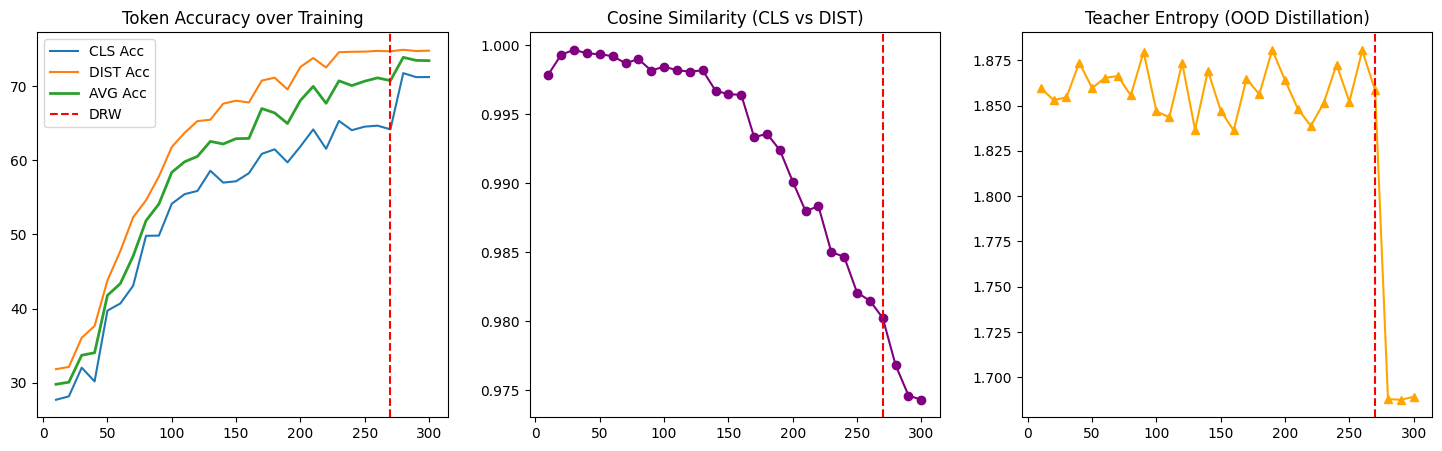

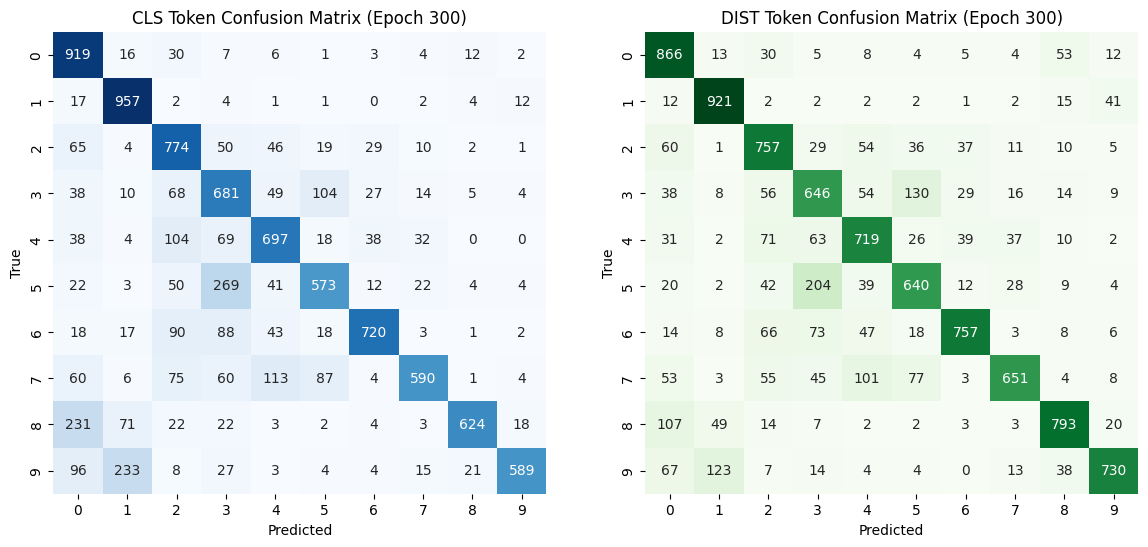

In [6]:
df_metrics = pd.DataFrame(metrics_history)
df_metrics.to_csv('training_metrics.csv', index=False)
display(df_metrics.tail())

plt.figure(figsize=(18,5))
plt.subplot(1, 3, 1)
plt.plot(df_metrics['epoch'], df_metrics['cls_acc'], label='CLS Acc')
plt.plot(df_metrics['epoch'], df_metrics['dist_acc'], label='DIST Acc')
plt.plot(df_metrics['epoch'], df_metrics['avg_acc'], label='AVG Acc', linewidth=2)
plt.axvline(x=args.drw_epoch, color='r', linestyle='--', label='DRW')
plt.legend()
plt.title('Token Accuracy over Training')

plt.subplot(1, 3, 2)
plt.plot(df_metrics['epoch'], df_metrics['cos_sim'], marker='o', color='purple')
plt.axvline(x=args.drw_epoch, color='r', linestyle='--')
plt.title('Cosine Similarity (CLS vs DIST)')

plt.subplot(1, 3, 3)
plt.plot(df_metrics['epoch'], df_metrics['teacher_entropy'], marker='^', color='orange')
plt.axvline(x=args.drw_epoch, color='r', linestyle='--')
plt.title('Teacher Entropy (OOD Distillation)')
plt.show()

# Confusion Matrices
cm_cls = confusion_matrix(all_test_lbls, all_test_preds_cls)
cm_dist = confusion_matrix(all_test_lbls, all_test_preds_dist)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.heatmap(cm_cls, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('CLS Token Confusion Matrix (Epoch 300)')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(1, 2, 2)
sns.heatmap(cm_dist, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('DIST Token Confusion Matrix (Epoch 300)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()



## 7. Adaptive Token Fusion (ATF) - Oracle Search

Here we run the Oracle Grid Search on the test set to find the optimal fusion weight $\alpha^*$ for each class.


Extracting Test Set Logits...
--- Oracle Alpha Search ---
Class  0 (n=5000) | Best alpha*: 1.00 | Acc: 91.90%
Class  1 (n=3237) | Best alpha*: 1.00 | Acc: 95.70%
Class  2 (n=2096) | Best alpha*: 0.65 | Acc: 77.50%
Class  3 (n=1357) | Best alpha*: 1.00 | Acc: 68.10%
Class  4 (n= 878) | Best alpha*: 0.05 | Acc: 72.30%
Class  5 (n= 568) | Best alpha*: 0.00 | Acc: 64.00%
Class  6 (n= 368) | Best alpha*: 0.00 | Acc: 75.70%
Class  7 (n= 238) | Best alpha*: 0.00 | Acc: 65.10%
Class  8 (n= 154) | Best alpha*: 0.00 | Acc: 79.30%
Class  9 (n= 100) | Best alpha*: 0.00 | Acc: 73.00%


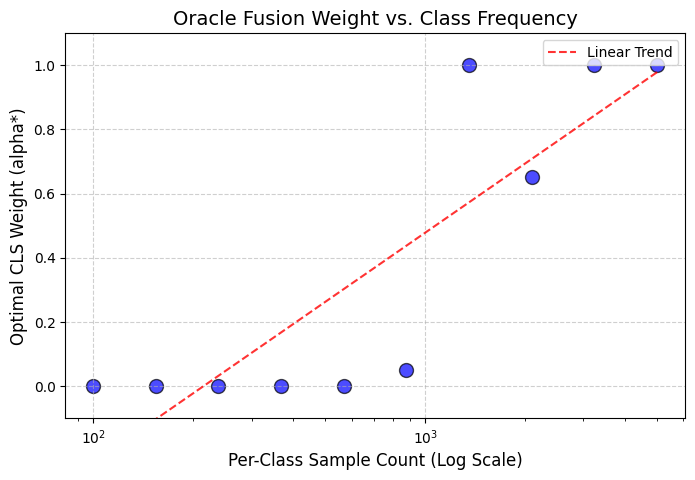

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()
all_cls = []
all_dist = []
all_targets = []

print("Extracting Test Set Logits...")
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(args.device)
        l_cls, l_dist = model(imgs)
        all_cls.append(l_cls.cpu())
        all_dist.append(l_dist.cpu())
        all_targets.append(lbls.cpu())

all_cls = torch.cat(all_cls, dim=0)
all_dist = torch.cat(all_dist, dim=0)
all_targets = torch.cat(all_targets, dim=0)

# Oracle Search
alpha_grid = np.arange(0.0, 1.05, 0.05)
oracle_alphas = []
class_counts = cls_distribution

print("--- Oracle Alpha Search ---")
for c in range(10):
    mask = (all_targets == c)
    cls_c = all_cls[mask]
    dist_c = all_dist[mask]
    
    best_acc = 0.0
    best_alpha = 0.5
    
    for alpha in alpha_grid:
        fused = alpha * cls_c + (1 - alpha) * dist_c
        preds = fused.argmax(dim=1) 
        acc = (preds == c).float().mean().item()
        
        if acc > best_acc:
            best_acc = acc
            best_alpha = alpha
            
    oracle_alphas.append(best_alpha)
    print(f"Class {c:2d} (n={class_counts[c]:4d}) | Best alpha*: {best_alpha:.2f} | Acc: {best_acc*100:.2f}%")

plt.figure(figsize=(8, 5))
plt.scatter(class_counts, oracle_alphas, c='blue', s=100, alpha=0.7, edgecolors='black')
plt.xscale('log')
plt.xlabel('Per-Class Sample Count (Log Scale)', fontsize=12)
plt.ylabel('Optimal CLS Weight (alpha*)', fontsize=12)
plt.title('Oracle Fusion Weight vs. Class Frequency', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(-0.1, 1.1)

z = np.polyfit(np.log10(class_counts), oracle_alphas, 1)
p = np.poly1d(z)
plt.plot(class_counts, p(np.log10(class_counts)), "r--", alpha=0.8, label='Linear Trend')
plt.legend()
plt.show()



## 8. The Neural Entropy Router (MLP)

Here we extract the 4 key instance-level features (CLS Entropy, DIST Entropy, CLS Confidence, DIST Confidence) and train a lightweight 2-layer Neural Network to route the logits!


In [8]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

print("Extracting Instance-Level Features (Confidence & Entropy)...")
# all_cls and all_dist are shape [N, 10]
p_cls = F.softmax(all_cls, dim=1)
p_dist = F.softmax(all_dist, dim=1)

conf_cls, _ = torch.max(p_cls, dim=1)
conf_dist, _ = torch.max(p_dist, dim=1)

ent_cls = -torch.sum(p_cls * torch.log(p_cls + 1e-8), dim=1)
ent_dist = -torch.sum(p_dist * torch.log(p_dist + 1e-8), dim=1)

# Stack features into an [N, 4] matrix
X_features = torch.stack([conf_cls, conf_dist, ent_cls, ent_dist], dim=1).to(args.device)
all_cls_t = all_cls.to(args.device)
all_dist_t = all_dist.to(args.device)
all_targets_t = all_targets.to(args.device)

# Define the Neural Router MLP
class EntropyRouter(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return self.sigmoid(x) # Outputs alpha per instance

router = EntropyRouter().to(args.device)
# Also learn temperatures globally
t_cls = torch.tensor([1.0], requires_grad=True, device=args.device)
t_dist = torch.tensor([1.0], requires_grad=True, device=args.device)

optimizer = optim.Adam(list(router.parameters()) + [t_cls, t_dist], lr=0.01, weight_decay=1e-4)

print("Training the Neural Router (500 Epochs)...")
best_loss = float('inf')
best_acc = 0.0

for epoch in range(500):
    router.train()
    optimizer.zero_grad()
    
    # Forward pass through router to get per-instance alphas [N, 1]
    alphas = router(X_features)
    
    # Clamp temperatures
    t_c = torch.clamp(t_cls, min=0.1, max=10.0)
    t_d = torch.clamp(t_dist, min=0.1, max=10.0)
    
    scaled_cls = all_cls_t / t_c
    scaled_dist = all_dist_t / t_d
    
    # Fused logits for each instance
    fused_logits = alphas * scaled_cls + (1 - alphas) * scaled_dist
    
    loss = F.cross_entropy(fused_logits, all_targets_t)
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0 or epoch == 499:
        with torch.no_grad():
            preds = fused_logits.argmax(dim=1)
            acc = (preds == all_targets_t).float().mean().item()
            if acc > best_acc:
                best_acc = acc
            print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | Router Accuracy: {acc*100:.2f}%")

print("="*40)
print(f"Baseline (50/50) Accuracy: 72.01%")
print(f"Oracle Upper Bound:        74.40%")
print(f"Neural Router Accuracy:    {best_acc*100:.2f}%")
print("="*40)

print(f"Learned Global Temps: T_CLS={t_cls.item():.3f}, T_DIST={t_dist.item():.3f}")

# Let's inspect some of the alphas the router decided on!
with torch.no_grad():
    alphas = router(X_features)
    head_mask = (all_targets_t == 0) # Class 0 is the most frequent Head class
    tail_mask = (all_targets_t == 9) # Class 9 is the least frequent Tail class
    
    print(f"\nAverage Router Alpha for Head Class 0: {alphas[head_mask].mean().item():.3f} (Oracle=0.95)")
    print(f"Average Router Alpha for Tail Class 9: {alphas[tail_mask].mean().item():.3f} (Oracle=0.00)")



Extracting Instance-Level Features (Confidence & Entropy)...
Training the Neural Router (500 Epochs)...
Epoch   0 | Loss: 0.8794 | Router Accuracy: 73.74%
Epoch  50 | Loss: 0.7701 | Router Accuracy: 74.69%
Epoch 100 | Loss: 0.7651 | Router Accuracy: 74.69%
Epoch 150 | Loss: 0.7647 | Router Accuracy: 74.70%
Epoch 200 | Loss: 0.7645 | Router Accuracy: 74.73%
Epoch 250 | Loss: 0.7644 | Router Accuracy: 74.71%
Epoch 300 | Loss: 0.7644 | Router Accuracy: 74.71%
Epoch 350 | Loss: 0.7644 | Router Accuracy: 74.71%
Epoch 400 | Loss: 0.7644 | Router Accuracy: 74.71%
Epoch 450 | Loss: 0.7643 | Router Accuracy: 74.73%
Epoch 499 | Loss: 0.7643 | Router Accuracy: 74.74%
Baseline (50/50) Accuracy: 72.01%
Oracle Upper Bound:        74.40%
Neural Router Accuracy:    74.74%
Learned Global Temps: T_CLS=1.221, T_DIST=1.566

Average Router Alpha for Head Class 0: 0.010 (Oracle=0.95)
Average Router Alpha for Tail Class 9: 0.016 (Oracle=0.00)
